# Galaxies vs quasars (but with Neural Networks)

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import os

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

import sklearn
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_curve

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split

%matplotlib inline
%config InlineBackend.figure_format='retina'

Data are SDSS measurements in different bands and class GALAXY or QSO (which I'll write respectively as 0 or 1)

In [2]:
data = pd.read_csv("galaxyquasar.csv")
data

,u,g,r,i,z,class,z1,zerr
0,18.97213,18.53676,18.58280,18.34936,18.29215,QSO,0.522819,0.000155
1,19.24592,17.47646,16.47817,16.04472,15.68851,GALAXY,0.122846,0.000028
2,19.43536,17.70268,16.91565,16.58327,16.39128,GALAXY,0.000000,0.000000
3,19.31626,18.18312,17.39591,16.94549,16.65395,GALAXY,0.147435,0.000009
4,19.28828,19.11188,18.88937,18.80013,18.49183,QSO,2.011455,0.000631
...,...,...,...,...,...,...,...,...
49995,19.37295,18.12382,17.39886,16.98503,16.70585,GALAXY,0.113016,0.000011
49996,18.52021,16.88262,16.03280,15.56884,15.22454,GALAXY,0.085063,0.000014
49997,18.62718,17.30876,16.87371,16.62399,16.42296,GALAXY,0.054429,0.000008
49998,19.55140,18.27711,17.62101,17.21947,17.03347,GALAXY,0.112571,0.000009


In [3]:
le = LabelEncoder()

# Assign 1 or 0 to quasar or galaxy
data['class'] = le.fit_transform(data['class'])
labels = le.inverse_transform(data['class'])
class_names = le.classes_
print(class_names)

['GALAXY' 'QSO']


In [4]:
qso_gal=data['class'].to_numpy()
qso_gal

array([1, 0, 0, ..., 0, 0, 0])

In [5]:
colors=pd.read_csv("galaxyquasar.csv", usecols=["u","g","r","i","z"])
colors=colors.to_numpy()

In [6]:
colors

array([[18.97213, 18.53676, 18.5828 , 18.34936, 18.29215],
       [19.24592, 17.47646, 16.47817, 16.04472, 15.68851],
       [19.43536, 17.70268, 16.91565, 16.58327, 16.39128],
       ...,
       [18.62718, 17.30876, 16.87371, 16.62399, 16.42296],
       [19.5514 , 18.27711, 17.62101, 17.21947, 17.03347],
       [18.80772, 17.75751, 17.405  , 17.2165 , 17.12295]])

I subtract colors (u-g),(g-r),(r-i),(i-z) and these will be the 4 features of each object.

In [7]:
u_g=colors[:,0]-colors[:,1]
g_r=colors[:,1]-colors[:,2]
r_i=colors[:,2]-colors[:,3]
i_z=colors[:,3]-colors[:,4]

in L19 we observed the bimodality in the u-g feature and the fact that it was the most relevant feature

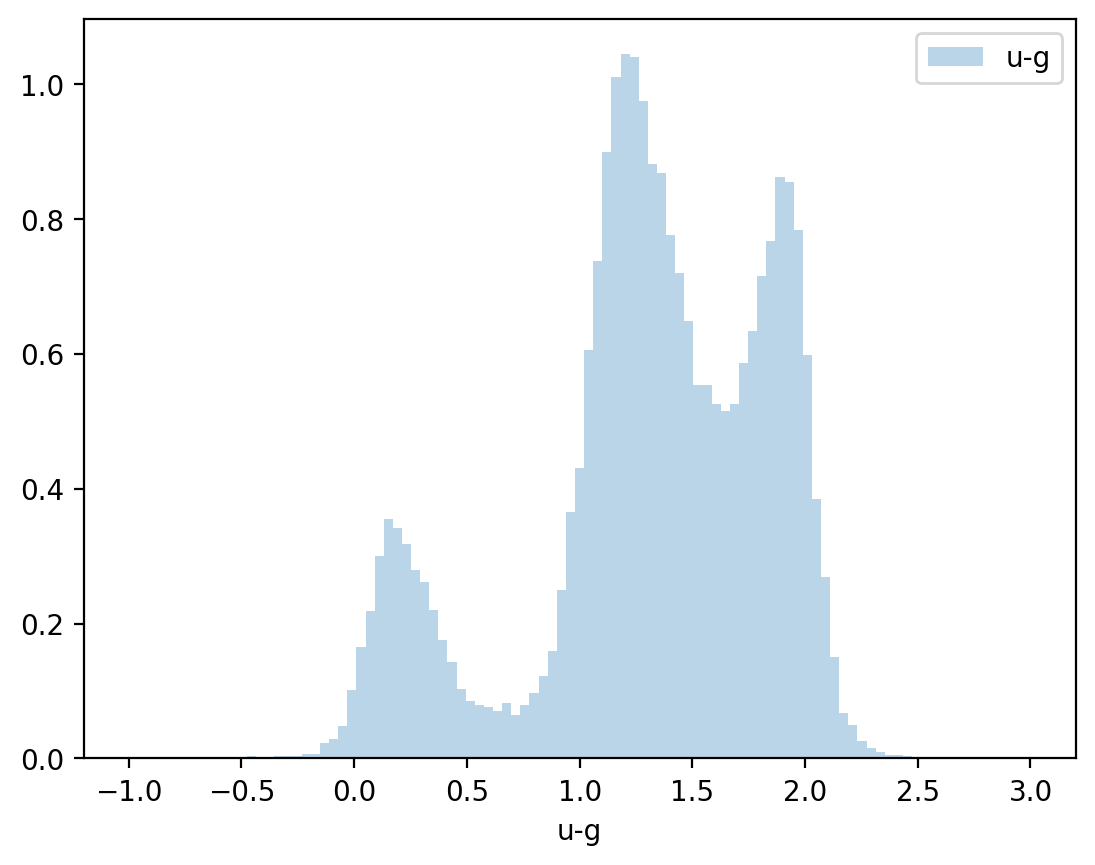

In [8]:
plt.hist(u_g,bins=np.linspace(-1,3,100), label='u-g', alpha=0.3, density=True)
plt.xlabel('u-g')
plt.legend();

Quick visualization with labels (0=GAL, 1=QSO)

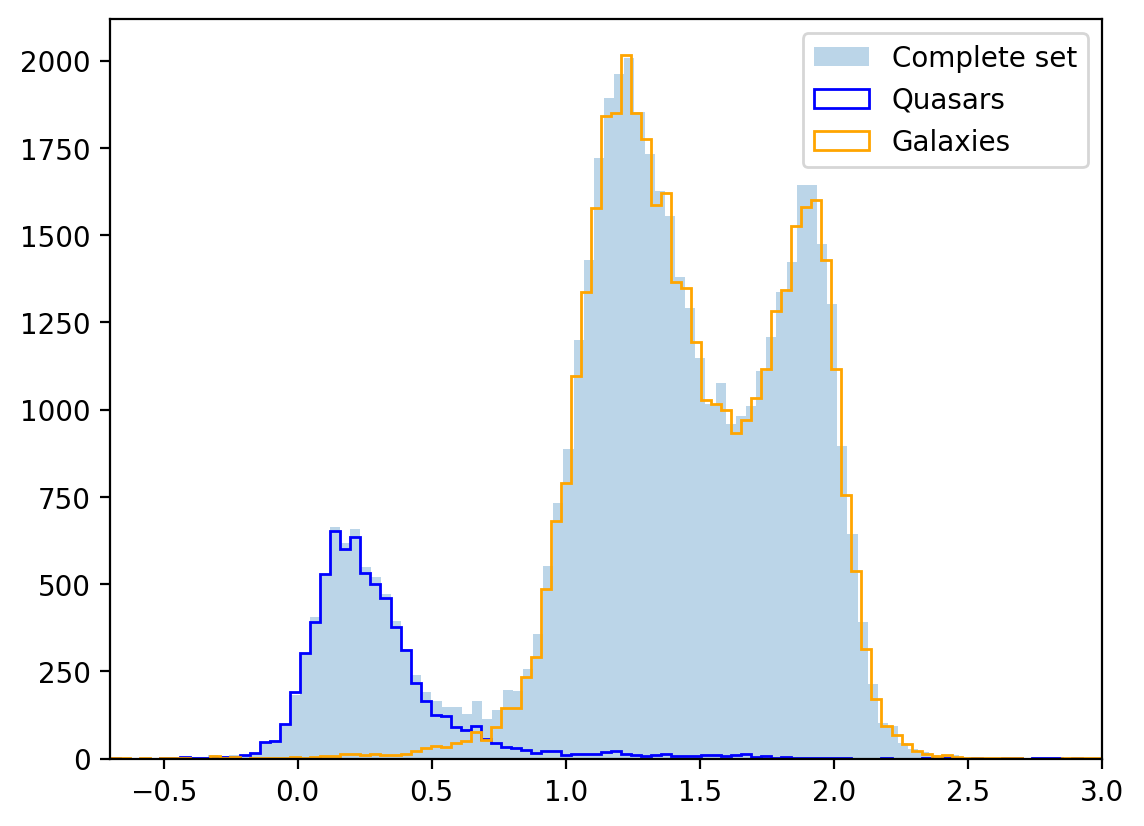

In [9]:
plt.hist(u_g, bins=200, label='Complete set', alpha=0.3)
plt.hist(u_g[qso_gal == 1], histtype='step', bins=np.linspace(-0.7, 3, 100), label='Quasars', color='blue')
plt.hist(u_g[qso_gal == 0], histtype='step', bins=np.linspace(-0.7, 3, 100), label='Galaxies', color='orange')

plt.xlim(-0.7, 3)
plt.legend()
plt.show()

And this is just normalized

Text(0.5, 0, 'u-g')

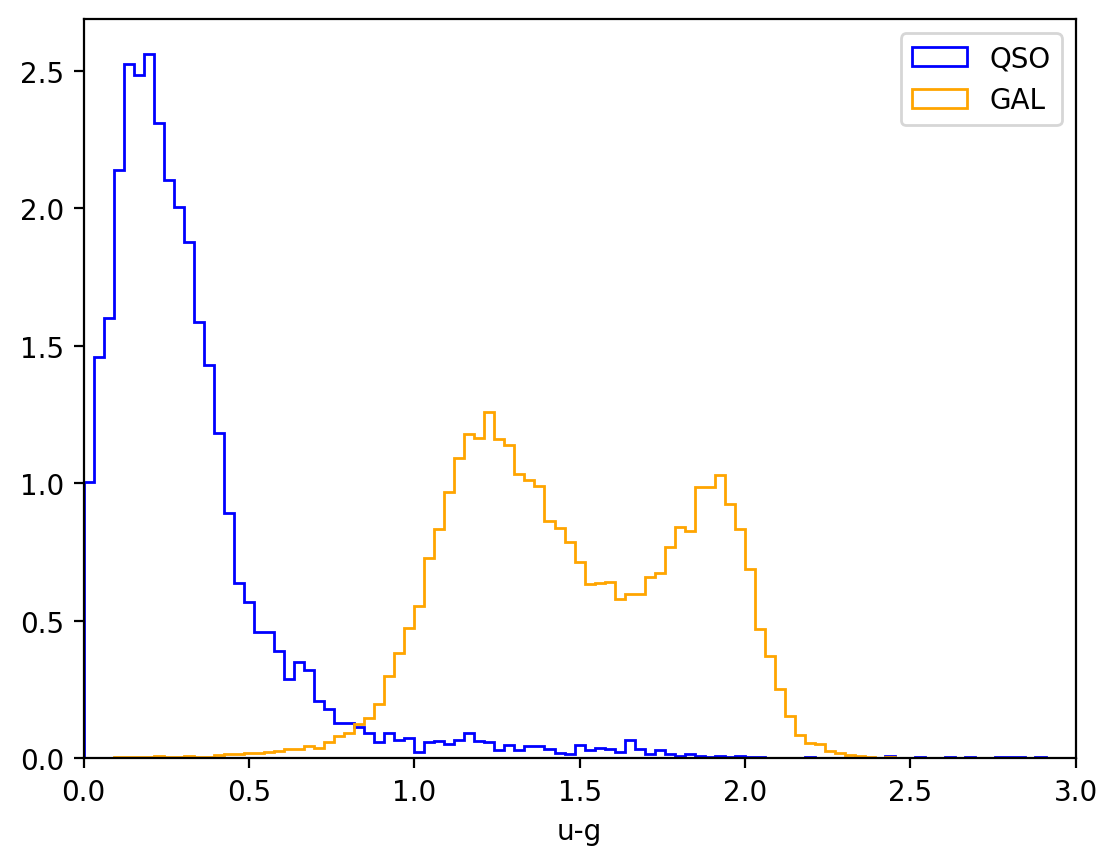

In [10]:
plt.hist(u_g[qso_gal==1],histtype='step',bins=np.linspace(0,3,100),density=True, color='blue',label='QSO')
plt.hist(u_g[qso_gal==0],histtype='step',bins=np.linspace(0,3,100),density=True, color='orange', label='GAL')
plt.xlim(0,3)
plt.legend()
plt.xlabel('u-g')

four features (full dataset)

In [11]:
X = np.column_stack((u_g, g_r, r_i, i_z))
X

array([[ 0.43537, -0.04604,  0.23344,  0.05721],
       [ 1.76946,  0.99829,  0.43345,  0.35621],
       [ 1.73268,  0.78703,  0.33238,  0.19199],
       ...,
       [ 1.31842,  0.43505,  0.24972,  0.20103],
       [ 1.27429,  0.6561 ,  0.40154,  0.186  ],
       [ 1.05021,  0.35251,  0.1885 ,  0.09355]])

Prepare data for NN: zero mean and unit variance

In [12]:
X_scaled = StandardScaler().fit_transform(X)

In [13]:
X_scaled

array([[-1.60092898, -2.18563716, -0.50654725, -0.6597534 ],
       [ 0.83890478,  1.18766393,  0.41731455,  0.4766113 ],
       [ 0.77164013,  0.50527082, -0.04953567, -0.14751516],
       ...,
       [ 0.01402593, -0.6316634 , -0.43134866, -0.11315818],
       [-0.06668067,  0.08235248,  0.26991977, -0.17028046],
       [-0.47648656, -0.8982767 , -0.71412862, -0.52164138]])

Test-train split (I split also the singe u-g feature because when I'll predict on the test set I'll try to visualize the result)

In [14]:
X_train, X_test, y_train, y_test, u_g_train, u_g_test = train_test_split(X_scaled, qso_gal, u_g, test_size=0.25, random_state=0)

In [15]:
X_train.shape

(37500, 4)

MLPClassifier (This model optimizes the log-loss function using LBFGS or stochastic gradient descent).
Taking guesses on the hyperparameters:
- 1 hidden layer with 100 units
- activation 'relu'
- solver 'adam'
- alpha = Strength of the L2 regularization term
- learning_rate (constant by default) 0.01 (initial learning rate used, it controls the step-size in updating the weights)
- max iterations 500 (the solver iterates until convergence or this number of iterations. For ‘sgd’, ‘adam’ this determines the number of epochs (how many times each data point will be used), not the number of gradient steps)

In [16]:
clf = sklearn.neural_network.MLPClassifier(
    hidden_layer_sizes=(100), 
    activation='relu',
    solver='adam',
    alpha=0,
    learning_rate_init=0.01,
    max_iter=500)

First I train my NN on 1000 datapoints, because I am taking guesses on hyperparameters

In [17]:
clf.fit(X_train[:1000], y_train[:1000])

MLPClassifier(alpha=0, hidden_layer_sizes=100, learning_rate_init=0.01,
              max_iter=500)

In [18]:
y_prob=clf.predict_proba(X_test)[:,1]

(0.9, 1.0)

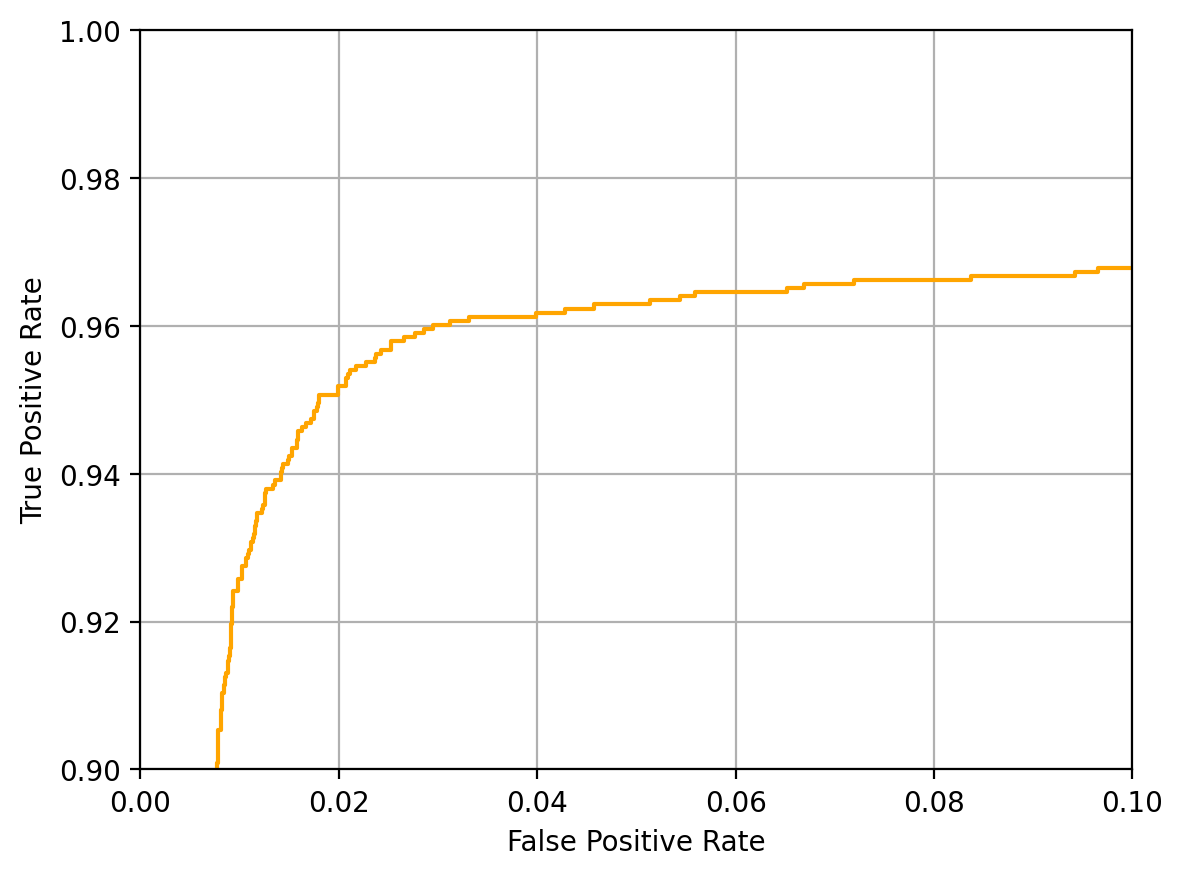

In [19]:
fpr, tpr, thresh = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, color='orange')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid()
plt.xlim(0,0.1)
plt.ylim(0.9,1)

In [20]:
clf.get_params()

{'activation': 'relu',
 'alpha': 0,
 'batch_size': 'auto',
 'beta_1': 0.9,
 'beta_2': 0.999,
 'early_stopping': False,
 'epsilon': 1e-08,
 'hidden_layer_sizes': 100,
 'learning_rate': 'constant',
 'learning_rate_init': 0.01,
 'max_fun': 15000,
 'max_iter': 500,
 'momentum': 0.9,
 'n_iter_no_change': 10,
 'nesterovs_momentum': True,
 'power_t': 0.5,
 'random_state': None,
 'shuffle': True,
 'solver': 'adam',
 'tol': 0.0001,
 'validation_fraction': 0.1,
 'verbose': False,
 'warm_start': False}

I'll try cross validation to pick better hyperparameters

In [21]:
parameters = {'activation':('logistic', 'relu', 'tanh'), 
              'hidden_layer_sizes':[100, (20,20), (5,5), (10,10,10)], 
              'learning_rate_init':[0.1,0.01,0.001], 
              'solver': ('sgd', 'adam')}

grid_search = GridSearchCV(clf, parameters, cv=5, scoring='accuracy', n_jobs=-1)

grid_search.fit(X_train[:1000], y_train[:1000])


/Users/beatricetonello/opt/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/beatricetonello/opt/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/beatricetonello/opt/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/beatricetonello/opt/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged ye

GridSearchCV(cv=5,
             estimator=MLPClassifier(alpha=0, hidden_layer_sizes=100,
                                     learning_rate_init=0.01, max_iter=500),
             n_jobs=-1,
             param_grid={'activation': ('logistic', 'relu', 'tanh'),
                         'hidden_layer_sizes': [100, (20, 20), (5, 5),
                                                (10, 10, 10)],
                         'learning_rate_init': [0.1, 0.01, 0.001],
                         'solver': ('sgd', 'adam')},
             scoring='accuracy')

In [22]:
print("Best par:", grid_search.best_params_)
print("Best accuracy:", grid_search.best_score_)

Best par: {'activation': 'relu', 'hidden_layer_sizes': (5, 5), 'learning_rate_init': 0.1, 'solver': 'sgd'}
Best accuracy: 0.992


In [23]:
bestclf = grid_search.best_estimator_

This should be better than naively guessing

In [24]:
bestclf

MLPClassifier(alpha=0, hidden_layer_sizes=(5, 5), learning_rate_init=0.1,
              max_iter=500, solver='sgd')

I try to fit

In [25]:
bestclf.fit(X_train, y_train)

MLPClassifier(alpha=0, hidden_layer_sizes=(5, 5), learning_rate_init=0.1,
              max_iter=500, solver='sgd')

In [26]:
y_prob=bestclf.predict_proba(X_test)[:,1]

(0.9, 1.0)

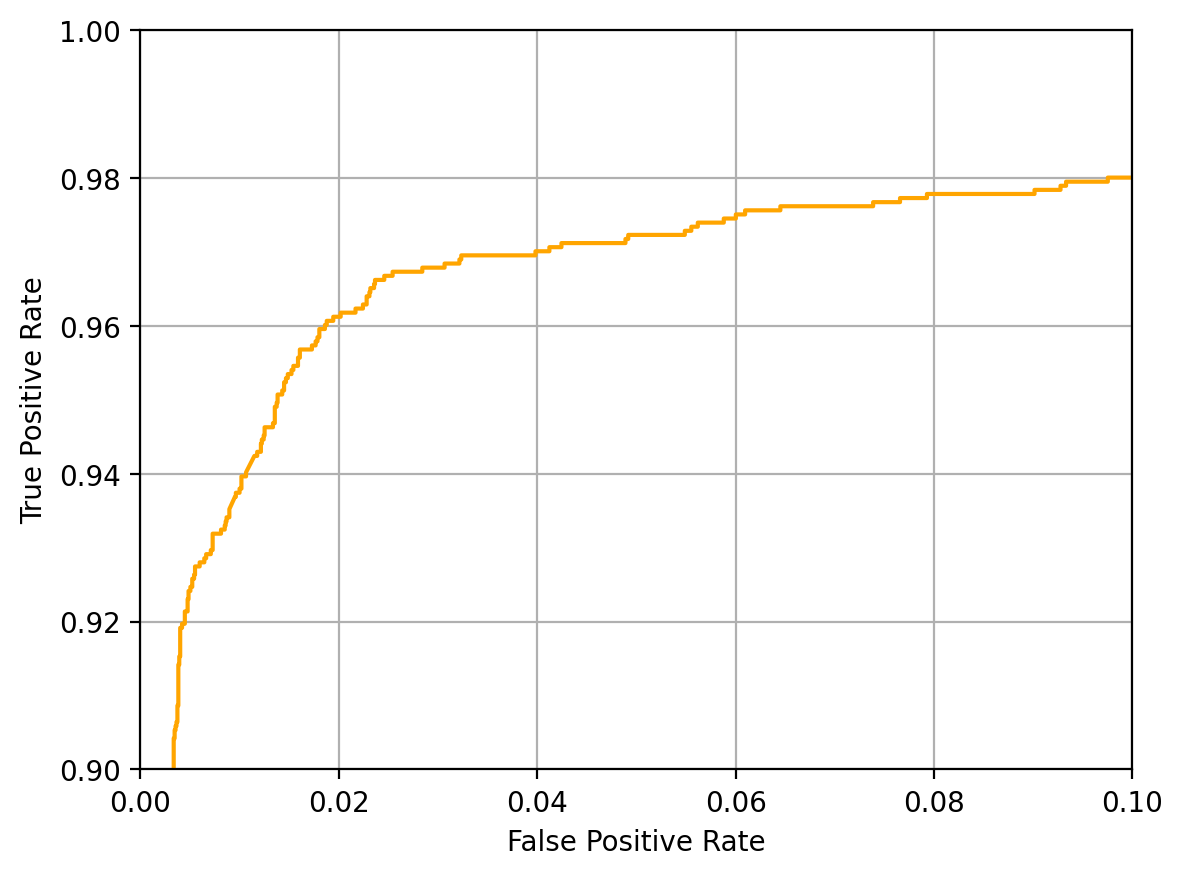

In [27]:
fpr, tpr, thresh = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, color='orange')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid()
plt.xlim(0,0.1)
plt.ylim(0.9,1)

This actually seems a bit better than before

first I predict on the full dataset, for visualization purposes

In [28]:
y_pred=bestclf.predict(X_scaled) #on the full dataset

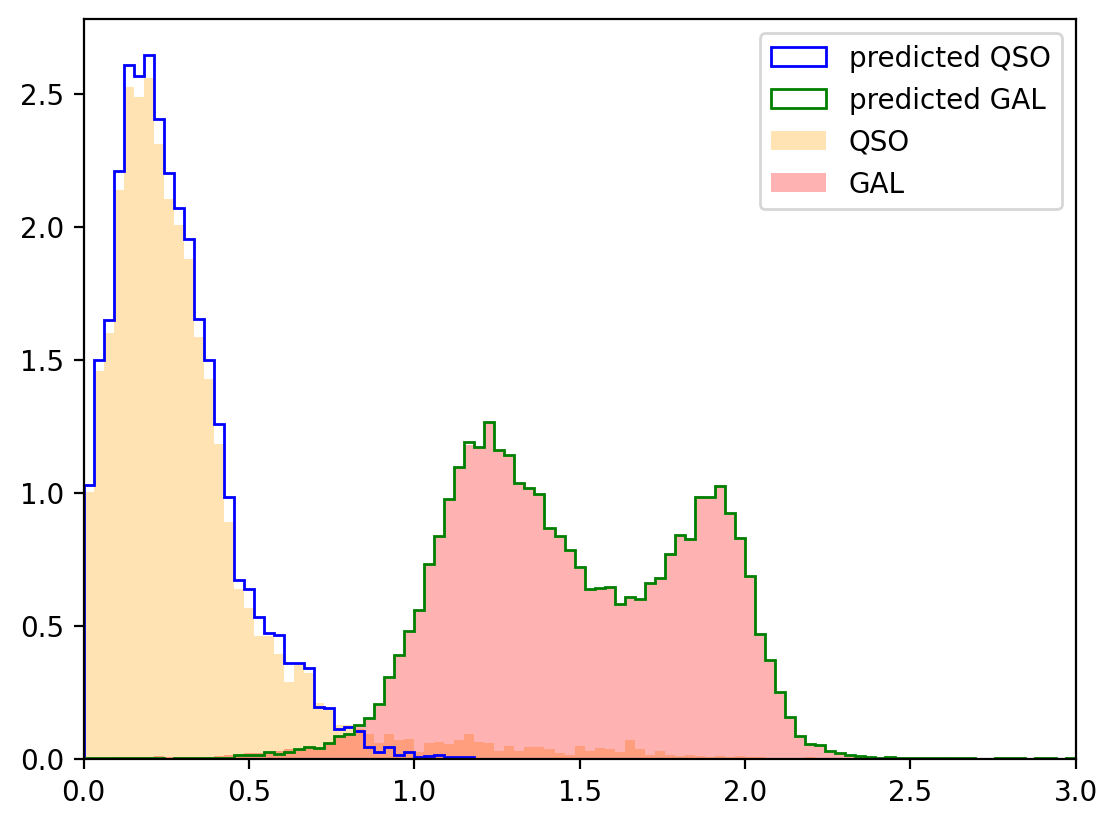

In [29]:
plt.hist(u_g[y_pred==1],histtype='step',bins=np.linspace(0,3,100), density=True,color='blue', label='predicted QSO')
plt.hist(u_g[y_pred==0],histtype='step',bins=np.linspace(0,3,100), density=True,color='green', label='predicted GAL')

plt.hist(u_g[labels=='QSO'],alpha=0.3,bins=np.linspace(0,3,100),density=True,color='orange', label='QSO')
plt.hist(u_g[labels=='GALAXY'],alpha=0.3,bins=np.linspace(0,3,100),density=True,color='red', label='GAL')
plt.xlim(0,3)
plt.legend()
plt.show()

The bimodality is recovered

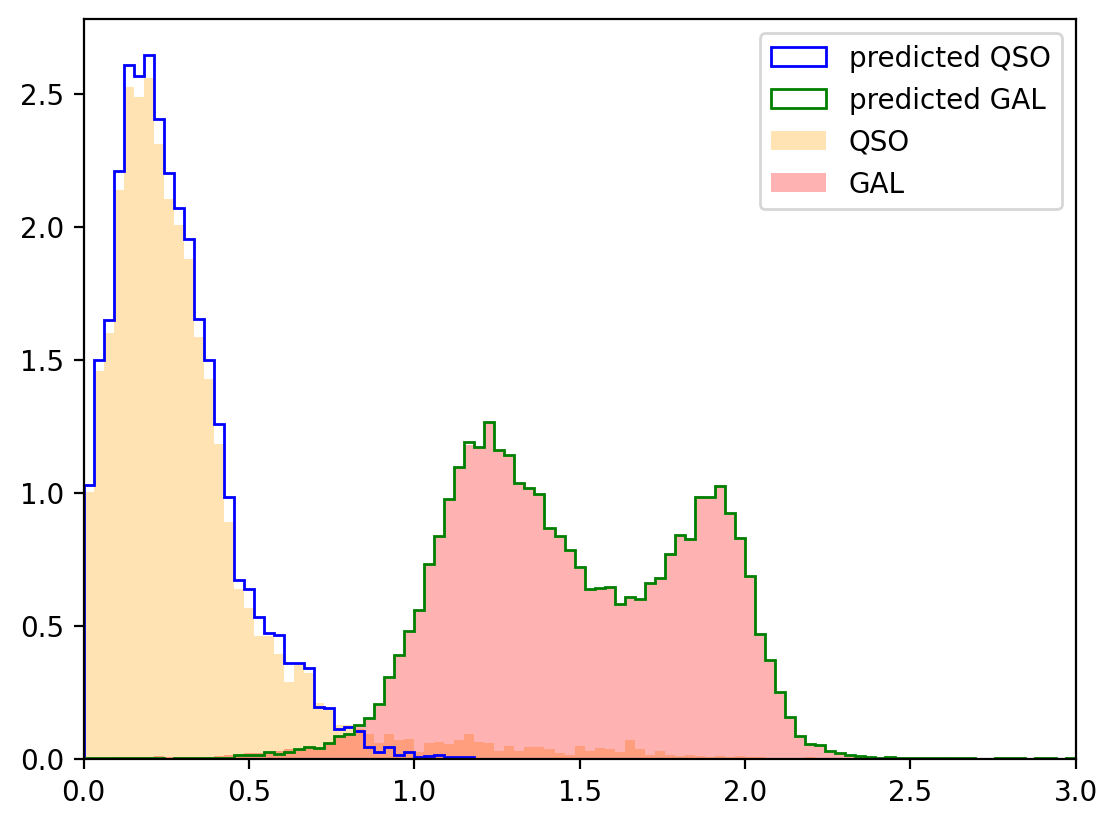

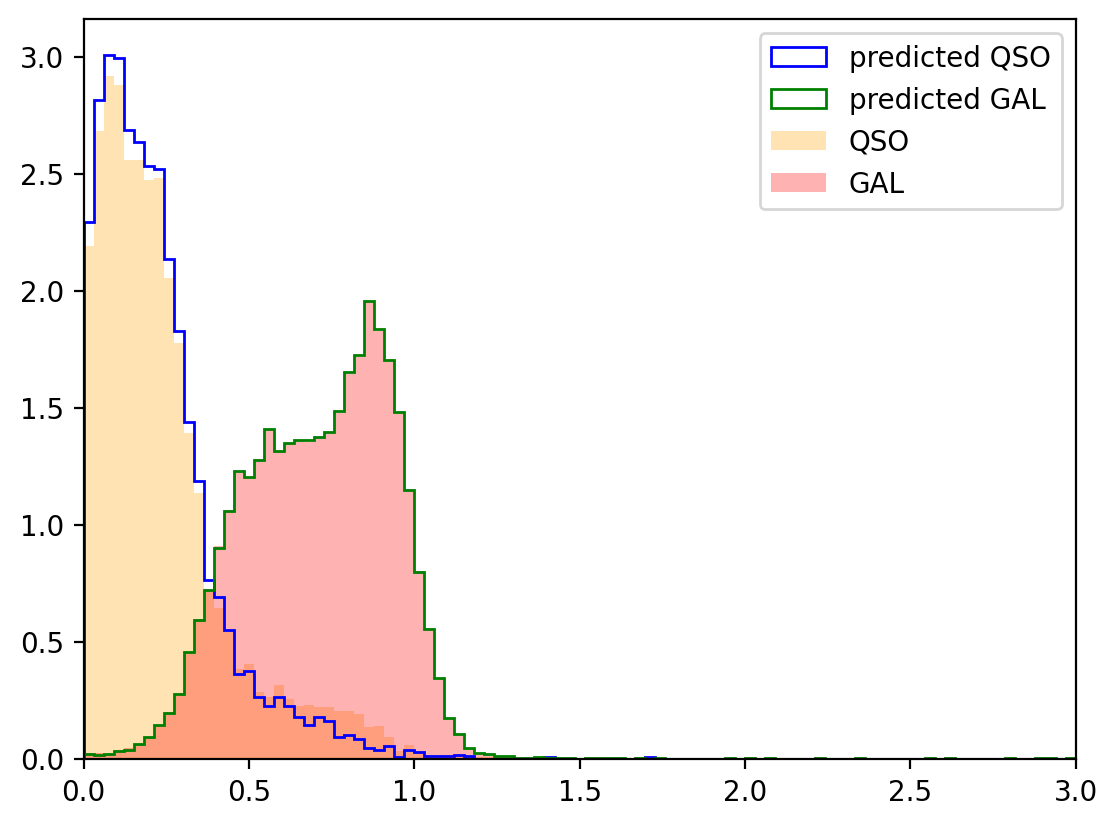

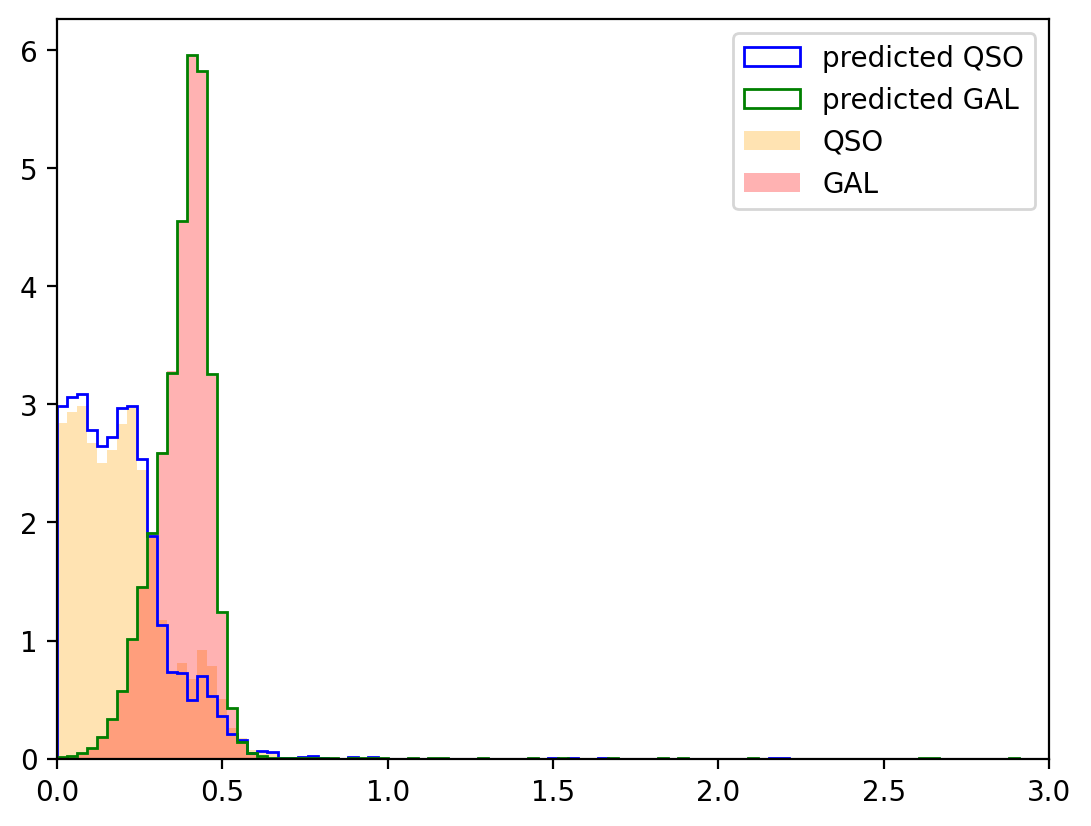

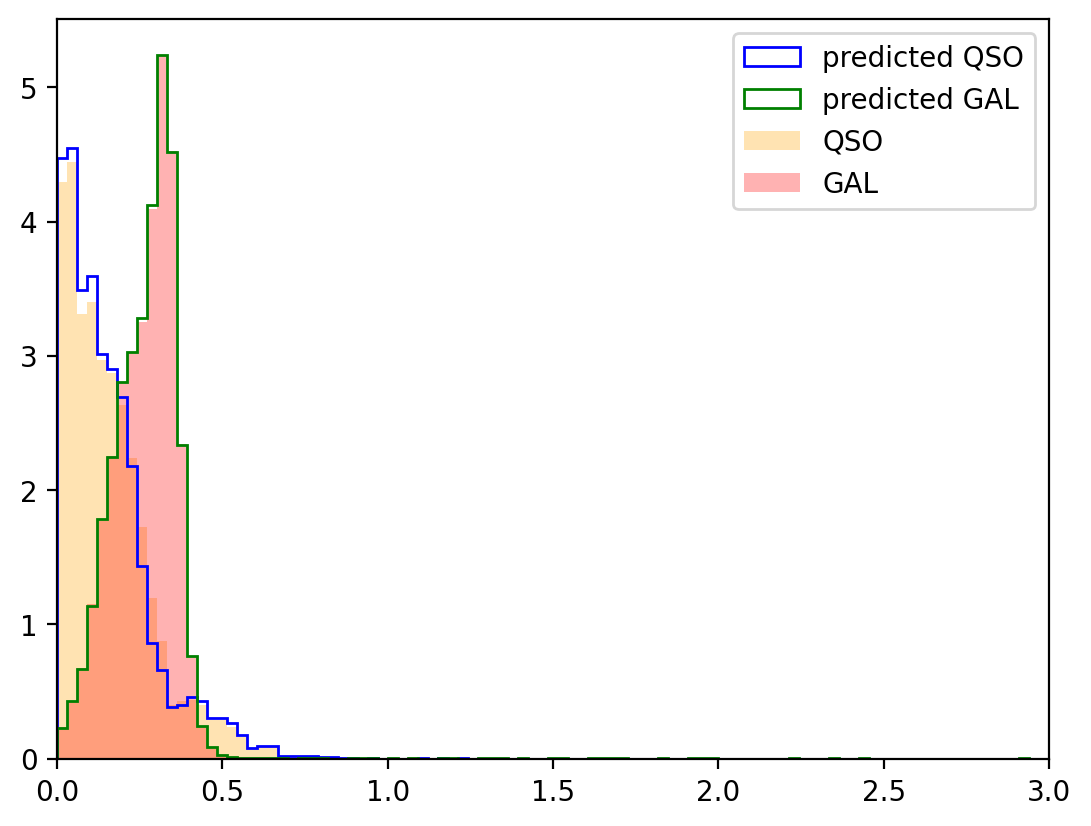

In [30]:
for col in [u_g, g_r, r_i, i_z]:

    plt.hist(col[y_pred==1],histtype='step',bins=np.linspace(0,3,100), density=True,color='blue', label='predicted QSO')
    plt.hist(col[y_pred==0],histtype='step',bins=np.linspace(0,3,100), density=True,color='green', label='predicted GAL')

    plt.hist(col[labels=='QSO'],alpha=0.3,bins=np.linspace(0,3,100),density=True,color='orange', label='QSO')
    plt.hist(col[labels=='GALAXY'],alpha=0.3,bins=np.linspace(0,3,100),density=True,color='red', label='GAL')
    plt.xlim(0,3)
    plt.legend()
    plt.show()

Now I predict on the test test, because I want to compare the performance of the NN with the GMMBayes Classifier of L19

In [31]:
y_pred=bestclf.predict(X_test)

In [32]:
y_pred.size

12500

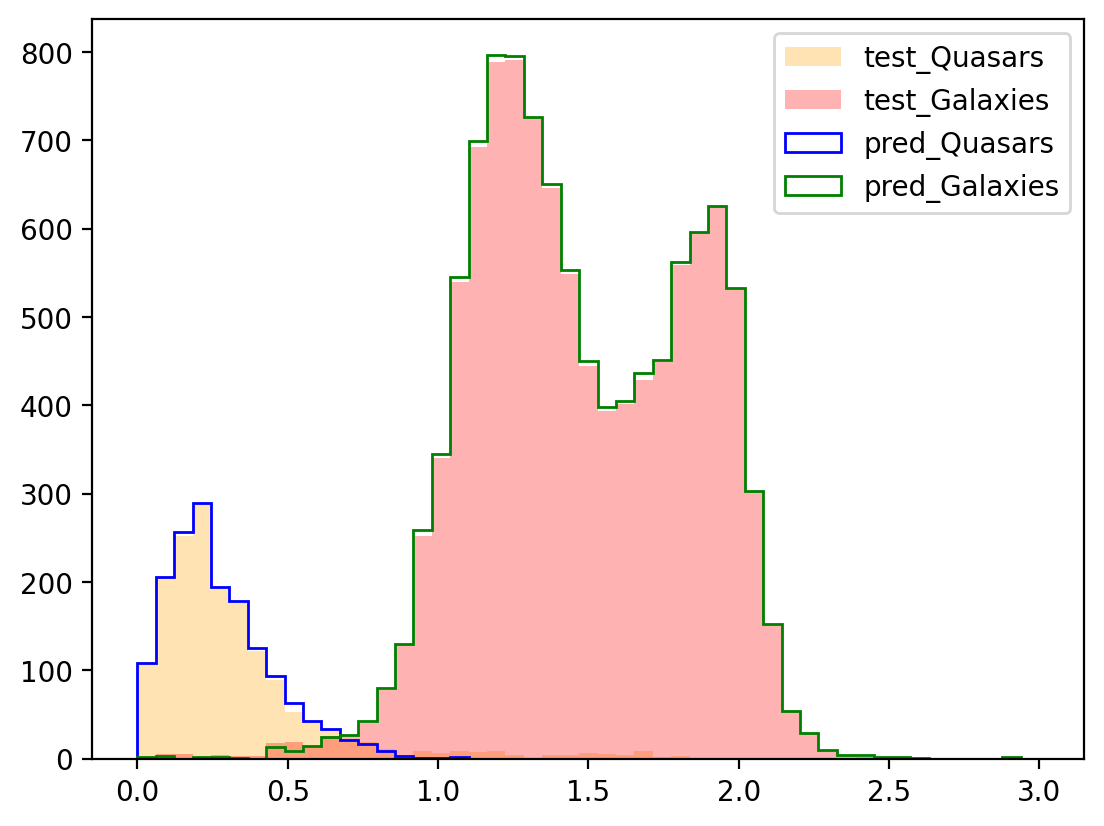

In [33]:
plt.hist(u_g_test[y_test == 1], alpha=0.3, bins=np.linspace(0,3,50), label='test_Quasars', color='orange')
plt.hist(u_g_test[y_test == 0], alpha=0.3, bins=np.linspace(0,3,50), label='test_Galaxies', color='red')
plt.hist(u_g_test[y_pred == 1], histtype='step', bins=np.linspace(0,3,50), label='pred_Quasars', color='blue')
plt.hist(u_g_test[y_pred == 0], histtype='step', bins=np.linspace(0,3,50), label='pred_Galaxies', color='green')
plt.legend()
plt.show();

In [34]:
C = sklearn.metrics.confusion_matrix(y_test, y_pred)
print('Confusion matrix:')
print(C)

Confusion matrix:
[[10621    73]
 [  128  1678]]


In [35]:
from sklearn.metrics import accuracy_score
accuracy_dt = accuracy_score(y_test, y_pred)
print('Accuracy:', accuracy_dt)

Accuracy: 0.98392


For the GMMBayes(6 components) classifier accuracy was = 0.98344

The NN accuracy is a bit better but they are actually kind of the same number, so probably I could just use a simple Classifier for this task.  
(I tried with other parameters in GridSearch and the accuracy of this test is always 0.983...)

I compute completeness/contamination on the test set and on the training set

In [36]:
from astroML.utils import completeness_contamination

comp_dt, cont_dt = completeness_contamination(y_pred, y_test)
print('Completeness test:', comp_dt)
print('Contamination test:', cont_dt)

Completeness test: 0.929125138427464
Contamination test: 0.04169046259280411


In [37]:
y_pred=bestclf.predict(X_train)

In [38]:
comp_dt, cont_dt = completeness_contamination(y_pred, y_train)
print('Completeness train:', comp_dt)
print('Contamination train:', cont_dt)

Completeness train: 0.9433183183183184
Contamination train: 0.039556659659850946


Completeness train/test and contamination train/test are the same

I'll try with another classifier that I didn't use in L19

In [39]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42, n_estimators=100)

rf.fit(X_train, y_train)

rf_train_accuracy = rf.score(X_train, y_train)
rf_test_accuracy = rf.score(X_test, y_test)

In [40]:
print('RandomForest Accuracy:', rf_test_accuracy)

RandomForest Accuracy: 0.98376
